=== Bayesian Matrix Factorization Project ===
1: Normal CPU version
2: GPU-accelerated version (PyTorch)
3: Minimal version (quick results)
Selected mode: cpu | device: cpu

Step 1/4: Load and preprocess data...
Users: 610, Movies: 9724, Train samples: 99616, Val samples: 1220

Step 2/4: Train Bayesian MF (Variational Inference)...


BMF (VI) Training: 100%|██████████| 90/90 [00:21<00:00,  4.15it/s]



Step 3/4: Train optimization baseline MF (Adam)...


MF Training: 100%|██████████| 90/90 [00:07<00:00, 11.55it/s]



Step 4/4: Evaluate and visualize...

Validation Metrics
BMF-VI continuous prediction:
  RMSE=1.0221, MSE=1.0448, MAE=0.7665
BMF-VI discrete(0.5-step) prediction:
  RMSE=1.0321, MSE=1.0652, MAE=0.7574
MF-Adam continuous prediction:
  RMSE=1.3091, MSE=1.7139, MAE=0.9784
MF-Adam discrete(0.5-step) prediction:
  RMSE=1.3285, MSE=1.7650, MAE=0.9766

Training time: BMF-VI=21.68s, MF-Adam=7.80s

Sample predictions on validation points:
True    BMF     BMF-disc    MF      MF-disc   
----------------------------------------------
3.0     3.89    4.0         4.88    5.0       
4.0     4.59    4.5         4.13    4.0       
4.0     4.12    4.0         4.26    4.5       
3.5     4.59    4.5         4.96    5.0       
4.0     3.93    4.0         3.16    3.0       
2.5     2.13    2.0         2.65    2.5       
3.5     1.09    1.0         1.10    1.0       
1.0     3.36    3.5         3.07    3.0       
5.0     4.43    4.5         3.15    3.0       
2.0     2.74    2.5         3.03    3.0       
3.

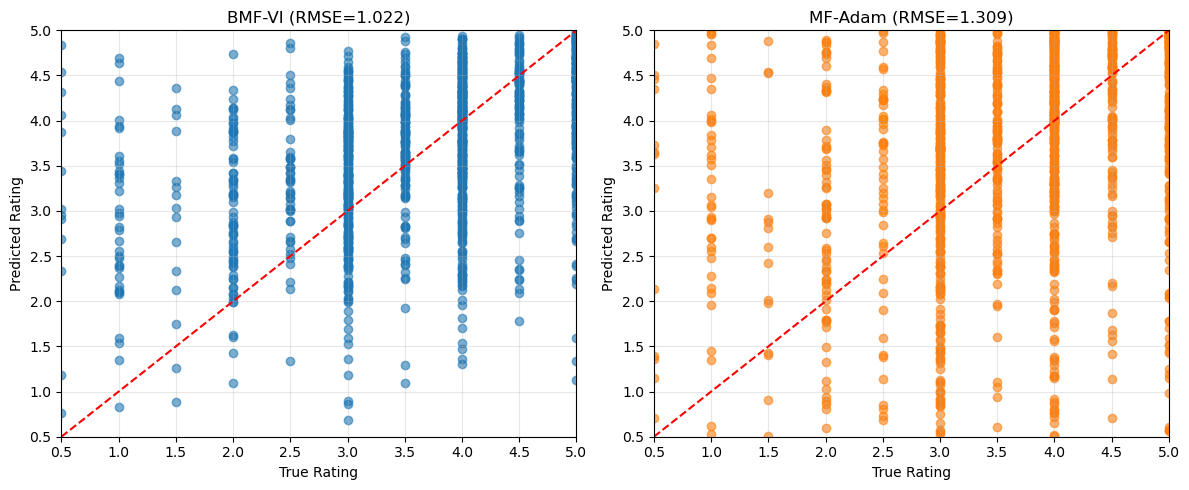


Output figure saved to 'BMF_MF_performance.png'.


In [1]:
import time
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from tqdm import tqdm

warnings.filterwarnings("ignore")


def to_discrete_half(pred_rating):
    return np.clip(np.round(pred_rating * 2.0) / 2.0, 0.5, 5.0)


def metrics(y_true, y_pred):
    mse = float(np.mean((y_true - y_pred) ** 2))
    rmse = float(np.sqrt(mse))
    mae = float(np.mean(np.abs(y_true - y_pred)))
    return {"mse": mse, "rmse": rmse, "mae": mae}


class Config:
    def __init__(self, mode):
        self.mode = mode
        self.K = 20 if mode != "minimal" else 12
        self.epochs = 90 if mode != "minimal" else 50
        self.batch_size = 4096 if mode != "minimal" else 1024
        self.lr_mf = 0.01
        self.lr_bmf = 0.004
        self.weight_decay = 1e-5
        self.beta_kl = 0.01
        self.obs_std = 0.12
        self.seed = int(time.time())
        self.min_users = 120
        self.min_movies = 280

        if mode == "gpu":
            self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        else:
            self.device = torch.device("cpu")

        torch.manual_seed(self.seed)
        np.random.seed(self.seed)


def load_data(config):
    df = pd.read_csv("ratings.csv")

    if config.mode == "minimal":
        users = df["userId"].value_counts().head(config.min_users).index
        movies = df["movieId"].value_counts().head(config.min_movies).index
        df = df[df["userId"].isin(users) & df["movieId"].isin(movies)].copy()

    user_ids = df["userId"].unique()
    movie_ids = df["movieId"].unique()
    user_map = {u: i for i, u in enumerate(user_ids)}
    movie_map = {m: i for i, m in enumerate(movie_ids)}

    df["u"] = df["userId"].map(user_map)
    df["m"] = df["movieId"].map(movie_map)
    df["r_ori"] = df["rating"].astype(np.float32)
    df["r_std"] = (df["r_ori"] - 0.5) / 4.5

    config.n_users = len(user_map)
    config.n_movies = len(movie_map)

    train_parts, val_parts = [], []
    for uid, sub in df.groupby("u", sort=False):
        sub = sub.sample(frac=1.0, random_state=config.seed)
        n_val = 1 if len(sub) <= 10 else 2
        val_parts.append(sub.iloc[:n_val])
        rest = sub.iloc[n_val:]
        if len(rest) == 0:
            rest = sub.iloc[:1]
        train_parts.append(rest)

    train_df = pd.concat(train_parts, ignore_index=True)
    val_df = pd.concat(val_parts, ignore_index=True)

    def to_tensor(part):
        u = torch.tensor(part["u"].values, dtype=torch.long, device=config.device)
        m = torch.tensor(part["m"].values, dtype=torch.long, device=config.device)
        r_std = torch.tensor(part["r_std"].values, dtype=torch.float32, device=config.device)
        r_ori = torch.tensor(part["r_ori"].values, dtype=torch.float32, device=config.device)
        return u, m, r_std, r_ori

    return to_tensor(train_df), to_tensor(val_df)


class StableMF(torch.nn.Module):
    def __init__(self, config):
        super().__init__()
        self.c = config
        self.U = torch.nn.Embedding(config.n_users, config.K)
        self.V = torch.nn.Embedding(config.n_movies, config.K)
        self.bu = torch.nn.Embedding(config.n_users, 1)
        self.bm = torch.nn.Embedding(config.n_movies, 1)
        self.global_logit = torch.nn.Parameter(torch.tensor(0.0, device=config.device))
        self.reset_parameters()

    def reset_parameters(self):
        torch.nn.init.normal_(self.U.weight, std=0.05)
        torch.nn.init.normal_(self.V.weight, std=0.05)
        torch.nn.init.zeros_(self.bu.weight)
        torch.nn.init.zeros_(self.bm.weight)

    def forward(self, u, m):
        dot = (self.U(u) * self.V(m)).sum(dim=1)
        logits = dot + self.bu(u).squeeze(-1) + self.bm(m).squeeze(-1) + self.global_logit
        pred_std = torch.sigmoid(logits)
        return pred_std

    def predict_rating(self, u, m):
        return self.forward(u, m) * 4.5 + 0.5

    def train_model(self, train_t, val_t):
        u_tr, m_tr, r_std_tr, _ = train_t
        u_va, m_va, _, r_ori_va = val_t
        n = u_tr.shape[0]
        optimizer = torch.optim.AdamW(
            self.parameters(),
            lr=self.c.lr_mf,
            weight_decay=self.c.weight_decay,
        )
        mse_loss = torch.nn.MSELoss()

        start = time.time()
        for _ in tqdm(range(self.c.epochs), desc="MF Training"):
            perm = torch.randperm(n, device=self.c.device)
            for s in range(0, n, self.c.batch_size):
                idx = perm[s:s + self.c.batch_size]
                pred_std = self.forward(u_tr[idx], m_tr[idx])
                loss = mse_loss(pred_std, r_std_tr[idx])
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

        with torch.no_grad():
            pred_cont = self.predict_rating(u_va, m_va).detach().cpu().numpy()
            pred_disc = to_discrete_half(pred_cont)
            true = r_ori_va.cpu().numpy()

        return {
            "pred_cont": pred_cont,
            "pred_disc": pred_disc,
            "true": true,
            "cont_metrics": metrics(true, pred_cont),
            "disc_metrics": metrics(true, pred_disc),
            "time": time.time() - start,
        }


class VariationalBayesianMF(torch.nn.Module):
    """
    Inexact Bayesian inference (variational approximation):
    q(U, V) = Π_i N(mu_u_i, diag(sigma_u_i^2)) Π_j N(mu_v_j, diag(sigma_v_j^2)).
    We maximize ELBO = E_q[log p(R|U,V)] - KL(q(U)||p(U)) - KL(q(V)||p(V)).
    """

    def __init__(self, config):
        super().__init__()
        self.c = config
        self.mu_u = torch.nn.Embedding(config.n_users, config.K)
        self.rho_u = torch.nn.Embedding(config.n_users, config.K)
        self.mu_v = torch.nn.Embedding(config.n_movies, config.K)
        self.rho_v = torch.nn.Embedding(config.n_movies, config.K)
        self.bu = torch.nn.Embedding(config.n_users, 1)
        self.bm = torch.nn.Embedding(config.n_movies, 1)
        self.global_logit = torch.nn.Parameter(torch.tensor(0.0, device=config.device))
        self.reset_parameters()

    def reset_parameters(self):
        torch.nn.init.normal_(self.mu_u.weight, std=0.04)
        torch.nn.init.normal_(self.mu_v.weight, std=0.04)
        torch.nn.init.constant_(self.rho_u.weight, -3.0)
        torch.nn.init.constant_(self.rho_v.weight, -3.0)
        torch.nn.init.zeros_(self.bu.weight)
        torch.nn.init.zeros_(self.bm.weight)

    @staticmethod
    def sigma_from_rho(rho):
        return torch.nn.functional.softplus(rho) + 1e-6

    def sample_factors(self, u, m):
        mu_u = self.mu_u(u)
        rho_u = self.rho_u(u)
        mu_v = self.mu_v(m)
        rho_v = self.rho_v(m)
        sig_u = self.sigma_from_rho(rho_u)
        sig_v = self.sigma_from_rho(rho_v)
        eps_u = torch.randn_like(sig_u)
        eps_v = torch.randn_like(sig_v)
        z_u = mu_u + sig_u * eps_u
        z_v = mu_v + sig_v * eps_v
        return z_u, z_v, mu_u, sig_u, mu_v, sig_v

    @staticmethod
    def kl_standard_normal(mu, sigma):
        return 0.5 * torch.sum(mu.pow(2) + sigma.pow(2) - 2.0 * torch.log(sigma) - 1.0)

    def forward_sample(self, u, m):
        z_u, z_v, mu_u, sig_u, mu_v, sig_v = self.sample_factors(u, m)
        logits = (z_u * z_v).sum(dim=1)
        logits = logits + self.bu(u).squeeze(-1) + self.bm(m).squeeze(-1) + self.global_logit
        pred_std = torch.sigmoid(logits)
        kl = self.kl_standard_normal(mu_u, sig_u) + self.kl_standard_normal(mu_v, sig_v)
        return pred_std, kl

    def predict_mean_rating(self, u, m):
        mu_u = self.mu_u(u)
        mu_v = self.mu_v(m)
        logits = (mu_u * mu_v).sum(dim=1)
        logits = logits + self.bu(u).squeeze(-1) + self.bm(m).squeeze(-1) + self.global_logit
        pred_std = torch.sigmoid(logits)
        return pred_std * 4.5 + 0.5

    def train_model(self, train_t, val_t):
        u_tr, m_tr, r_std_tr, _ = train_t
        u_va, m_va, _, r_ori_va = val_t
        n = u_tr.shape[0]
        optimizer = torch.optim.AdamW(
            self.parameters(),
            lr=self.c.lr_bmf,
            weight_decay=self.c.weight_decay,
        )

        start = time.time()
        for _ in tqdm(range(self.c.epochs), desc="BMF (VI) Training"):
            perm = torch.randperm(n, device=self.c.device)
            for s in range(0, n, self.c.batch_size):
                idx = perm[s:s + self.c.batch_size]
                pred_std, kl = self.forward_sample(u_tr[idx], m_tr[idx])
                recon = torch.mean((pred_std - r_std_tr[idx]) ** 2) / (2.0 * (self.c.obs_std ** 2))
                kl_scaled = self.c.beta_kl * kl / idx.numel()
                loss = recon + kl_scaled
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

        with torch.no_grad():
            pred_cont = self.predict_mean_rating(u_va, m_va).detach().cpu().numpy()
            pred_disc = to_discrete_half(pred_cont)
            true = r_ori_va.cpu().numpy()

        return {
            "pred_cont": pred_cont,
            "pred_disc": pred_disc,
            "true": true,
            "cont_metrics": metrics(true, pred_cont),
            "disc_metrics": metrics(true, pred_disc),
            "time": time.time() - start,
        }


def print_results(method_name, res):
    cm = res["cont_metrics"]
    dm = res["disc_metrics"]
    print(f"{method_name} continuous prediction:")
    print(f"  RMSE={cm['rmse']:.4f}, MSE={cm['mse']:.4f}, MAE={cm['mae']:.4f}")
    print(f"{method_name} discrete(0.5-step) prediction:")
    print(f"  RMSE={dm['rmse']:.4f}, MSE={dm['mse']:.4f}, MAE={dm['mae']:.4f}")


def show_samples(bmf_res, mf_res, n=15):
    idx = np.random.choice(len(bmf_res["true"]), size=min(n, len(bmf_res["true"])), replace=False)
    print("\nSample predictions on validation points:")
    print(f"{'True':<8}{'BMF':<8}{'BMF-disc':<12}{'MF':<8}{'MF-disc':<10}")
    print("-" * 46)
    for i in idx:
        t = bmf_res["true"][i]
        b = bmf_res["pred_cont"][i]
        bd = bmf_res["pred_disc"][i]
        m = mf_res["pred_cont"][i]
        md = mf_res["pred_disc"][i]
        print(f"{t:<8.1f}{b:<8.2f}{bd:<12.1f}{m:<8.2f}{md:<10.1f}")


def plot_compare(bmf_res, mf_res):
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.scatter(bmf_res["true"], bmf_res["pred_cont"], alpha=0.6, color="tab:blue")
    plt.plot([0.5, 5.0], [0.5, 5.0], "r--")
    plt.xlabel("True Rating")
    plt.ylabel("Predicted Rating")
    plt.title(f"BMF-VI (RMSE={bmf_res['cont_metrics']['rmse']:.3f})")
    plt.xlim(0.5, 5.0)
    plt.ylim(0.5, 5.0)
    plt.grid(alpha=0.3)

    plt.subplot(1, 2, 2)
    plt.scatter(mf_res["true"], mf_res["pred_cont"], alpha=0.6, color="tab:orange")
    plt.plot([0.5, 5.0], [0.5, 5.0], "r--")
    plt.xlabel("True Rating")
    plt.ylabel("Predicted Rating")
    plt.title(f"MF-Adam (RMSE={mf_res['cont_metrics']['rmse']:.3f})")
    plt.xlim(0.5, 5.0)
    plt.ylim(0.5, 5.0)
    plt.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig("BMF_MF_performance.png", dpi=300, bbox_inches="tight")
    plt.show()


def main():
    print("=== Bayesian Matrix Factorization Project ===")
    print("1: Normal CPU version")
    print("2: GPU-accelerated version (PyTorch)")
    print("3: Minimal version (quick results)")
    choice = input("Select mode (1/2/3): ").strip()
    mode = {"1": "cpu", "2": "gpu", "3": "minimal"}.get(choice, "minimal")
    cfg = Config(mode)
    print(f"Selected mode: {mode} | device: {cfg.device}")

    print("\nStep 1/4: Load and preprocess data...")
    train_t, val_t = load_data(cfg)
    print(f"Users: {cfg.n_users}, Movies: {cfg.n_movies}, Train samples: {len(train_t[0])}, Val samples: {len(val_t[0])}")

    print("\nStep 2/4: Train Bayesian MF (Variational Inference)...")
    bmf = VariationalBayesianMF(cfg).to(cfg.device)
    bmf_res = bmf.train_model(train_t, val_t)

    print("\nStep 3/4: Train optimization baseline MF (Adam)...")
    mf = StableMF(cfg).to(cfg.device)
    mf_res = mf.train_model(train_t, val_t)

    print("\nStep 4/4: Evaluate and visualize...")
    print("\n" + "=" * 66)
    print("Validation Metrics")
    print("=" * 66)
    print_results("BMF-VI", bmf_res)
    print_results("MF-Adam", mf_res)
    print(f"\nTraining time: BMF-VI={bmf_res['time']:.2f}s, MF-Adam={mf_res['time']:.2f}s")
    show_samples(bmf_res, mf_res)
    plot_compare(bmf_res, mf_res)
    print("\nOutput figure saved to 'BMF_MF_performance.png'.")


if __name__ == "__main__":
    main()